# EDA: Fashion & Style Survey

**Dataset:** Kaggle Fashion Dataset (rahul2312kaggle/fashion-dataset) — survey responses on clothing preferences, shopping habits, and personal style.

**Goal:** Understand the distribution of respondents, identify key patterns in shopping behavior, and surface insights that will inform our classification models.

**Sections:**
1. Data Loading & Cleaning
2. Dataset Overview
3. Distribution Plots
4. Key Relationships
5. Summary of Findings

## 1. Data Loading & cleaning

In [3]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
# Download latest version
path = kagglehub.dataset_download("rahul2312kaggle/fashion-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(Path(path) / "Fashion(Data Points) - Form responses 1.csv")

df.columns

Using Colab cache for faster access to the 'fashion-dataset' dataset.
Path to dataset files: /kaggle/input/fashion-dataset


Index(['Timestamp', '  1.Age Group  ', '  2.Gender  ', '  3.Profession  ',
       'Section 2: Style Preferences\n4. How would you describe your go-to daily outfit? (Select one)  ',
       ' 5. What’s your favorite color palette for clothing?  ',
       ' 6. Do you prioritize functionality or aesthetics in your outfits?  ',
       '  7.Which of these best describes your wardrobe?  ',
       'Section 3: Shopping Habits\n8. How often do you shop for new clothes?  ',
       '  9.What influences your clothing purchases the most?  ',
       ' 10. Where do you typically shop for clothes? (Select all that apply)  ',
       'Section 4: Lifestyle\n11. How often do you attend formal events?  ',
       '  12.Do you often experiment with new styles or stick to what you know?  ',
       ' 13. What kind of footwear do you wear most often?  ',
       '14. How active is your daily lifestyle?  ',
       'Section 5: Personal Preferences\n15. How important is comfort in your clothing choices\n',
       ' 

In [5]:
# Renaming columns
df = df.rename(columns={
    '  3.Profession  ': 'Profession',
    'Section 2: Style Preferences\n4. How would you describe your go-to daily outfit? (Select one)  ': 'Daily_outfit',
    ' 5. What\u2019s your favorite color palette for clothing?  ': 'Color_palette',
    ' 6. Do you prioritize functionality or aesthetics in your outfits?  ': 'Functionality_vs_aesthetics',
    '  7.Which of these best describes your wardrobe?  ': 'Wardrobe_type',
    'Section 3: Shopping Habits\n8. How often do you shop for new clothes?  ': 'Shopping_Frequency',
    '  9.What influences your clothing purchases the most?  ' : 'Influence',
    ' 10. Where do you typically shop for clothes? (Select all that apply)  ' : 'Stores',
    'Section 4: Lifestyle\n11. How often do you attend formal events?  ': 'Formal_event_attendance_frequency',
    '  12.Do you often experiment with new styles or stick to what you know?  ': 'Style_experimentation_frequency',
    ' 13. What kind of footwear do you wear most often?  ': 'Footwear',
    '14. How active is your daily lifestyle?  ': 'Activity Level',
    'Section 5: Personal Preferences\n15. How important is comfort in your clothing choices\n': 'Importance of Clothing',
    ' 16.If you had to choose, would you prefer timeless pieces or trendy items?  ': 'Trendy vs Timeless',
    '17. From scale 1-10 how much do you think your clothing style reflects about your personality?': 'Clothing on Personality'})

# Dropping the last two columns with mostly nan values
df.drop(columns = {'Timestamp', 'Section 2: Style Preferences', 'Column 18'}, inplace=True)

# Changing Clothing on Personality to int
df['Clothing on Personality'].fillna(df['Clothing on Personality'].mean()).astype(int)
df.head()

,1.Age Group,2.Gender,Profession,Daily_outfit,Color_palette,Functionality_vs_aesthetics,Wardrobe_type,Shopping_Frequency,Influence,Stores,Formal_event_attendance_frequency,Style_experimentation_frequency,Footwear,Activity Level,Importance of Clothing,Trendy vs Timeless,Clothing on Personality
0,18–24,Female,Student,"Chic (e.g., tailored, stylish)","Pastels (soft pink, baby blue)",Slightly prefer aesthetics,Mix-and-match (varied styles),Rarely,Comfort,Local boutiques,- Occasionally (a few times a year),Sometimes experiment,Sneakers,Mostly sedentary,- Extremely important,"Mostly trendy, some timeless",8.0
1,18–24,Female,Student,"Casual (e.g., jeans, t-shirts)","Dark tones (navy, maroon)",Slightly prefer functionality,Mix-and-match (varied styles),Every few months,Sustainability,Thrift stores,- Occasionally (a few times a year),Sometimes experiment,Sandals/Flats,Moderately active,- Somewhat important,"Mostly timeless, some trendy",6.0
2,18–24,Female,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Slightly prefer functionality,Minimalist (few versatile pieces),Monthly,Comfort,Local boutiques,- Occasionally (a few times a year),Rarely experiment,Sneakers,Moderately active,- Extremely important,"Mostly timeless, some trendy",9.0
3,18–24,Male,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Equal balance of both,Specialized (specific to one style),Every few months,Comfort,Thrift stores,- Rarely (less than once a year),Sometimes experiment,Sneakers,"Very active (e.g., gym, outdoor activities)",- Somewhat important,Always timeless,6.0
4,18–24,Male,Student,"Casual (e.g., jeans, t-shirts)","Neutral (black, white, beige)",Slightly prefer aesthetics,Minimalist (few versatile pieces),Rarely,Comfort,Thrift stores,- Occasionally (a few times a year),Rarely experiment,Sneakers,"Very active (e.g., gym, outdoor activities)",- Somewhat important,"Mostly timeless, some trendy",6.0


### Data Description
The dataset is a Google Form survey with ~150 respondents and 20 columns covering demographics, style preferences, shopping habits, lifestyle, and personal values.

We predict two demographic targets:

Age Group categorical (18-24, 25-34, 35-44, 45+)
Gender binary (Male / Female)
All remaining columns serve as predictive features.

## 2. Dataset Overview

Before diving into visualizations, we first check the dataset dimensions, data types, and missing values to understand what we're working with.

In [ ]:
taset shape and basic info
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names: {list(df.columns)}')
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

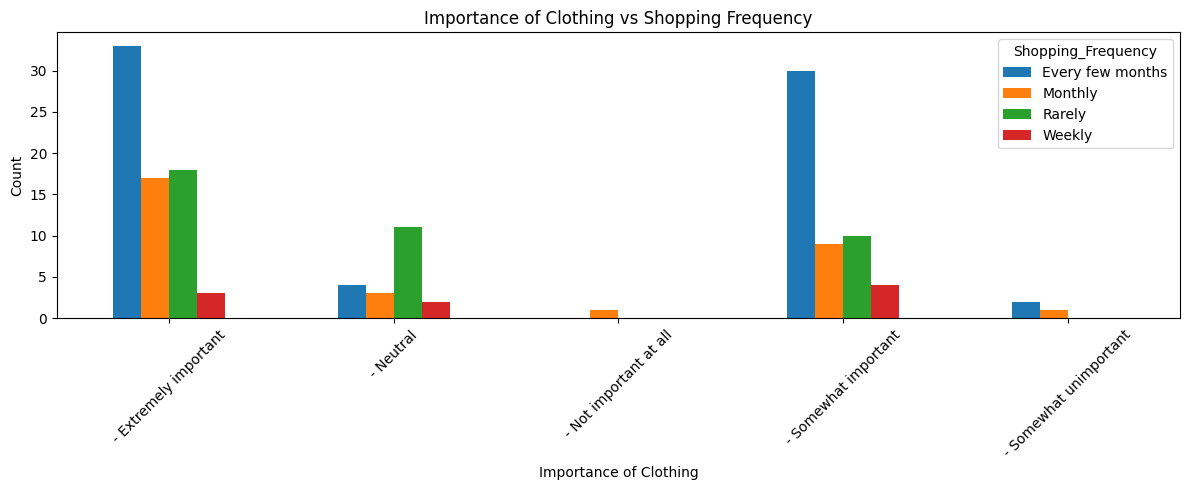

In [6]:
# Importance of clothing score on shopping frequency
df.groupby(['Importance of Clothing', 'Shopping_Frequency']).size().uns### Analysis: Importance of Clothing vs Shopping Frequency

Respondents who rate clothing as **extremely important** or **somewhat important** to their identity shop most frequently ("every few months" is the dominant pattern). This suggests that clothing importance is a reasonable predictor of shopping behavior — a key insight for our classification models.tack().plot(kind='bar', figsize=(12, 5))
plt.title('Importance of Clothing vs Shopping Frequency')
plt.xlabel('Importance of Clothing')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()


### Analysis: Importance of Clothing vs Shopping Frequency

Respondents who rate clothing as **extremely important** or **somewhat important** shop most frequently ("every few months" dominates both groups). Those who find clothing "not important at all" shop almost exclusively on a monthly or less frequent basis. This suggests clothing importance is a useful predictor of shopping behavior for our classification models.

Text(0.5, 0, 'Mean Score (1-10)')

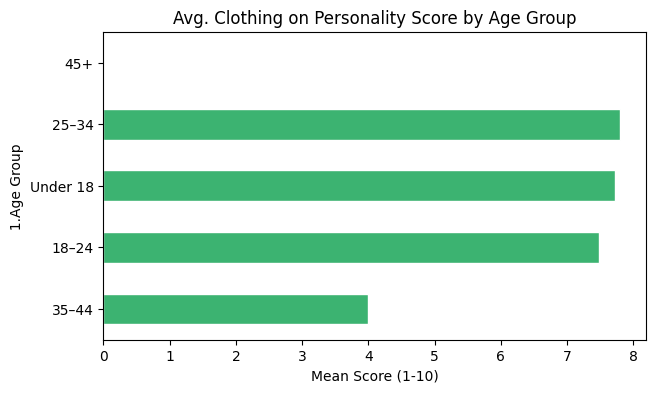

In [7]:
#  Style-Personality score by age group
df.groupby('  1.Age Group  ')['Clothing on Personality'].mean().sort_values().plot(
    kind='barh', figsize=(7, 4), color='mediumseagreen', edgecolor='white')
plt.title('Avg. Clothing on Personality Score by Age Group')
plt.xlabel('Mean Score (1-10)')

### Analysis: Avg. Clothing on Personality Score by Age Group

The 25-34 and Under-18 age groups show the highest mean scores (around 7.5-8/10), suggesting they view clothing as a strong expression of identity. The 35-44 group scores markedly lower (around 4/10). This age-based variation is notable and may be a useful segmentation feature for our classifiers.

Text(0.5, 0, 'Count')

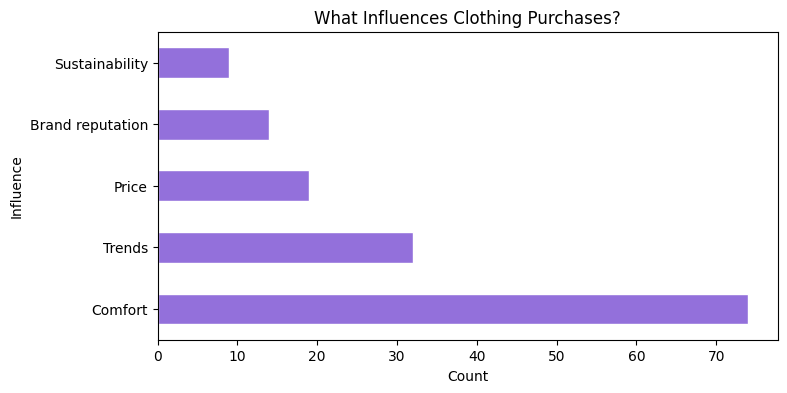

In [8]:
#  Top shopping influences
df['Influence'].value_counts().head(8).plot(
    kind='barh', figsize=(8, 4), color='mediumpurple', edgecolor='white')
plt.title('What Influences Clothing Purchases?')
plt.xlabel('Count')

### Analysis: What Influences Clothing Purchases?

**Comfort** is by far the dominant purchase driver (75 respondents), followed by Trends (30) and Price (18). Brand reputation and sustainability are minor factors. This strong comfort-first orientation will be an important feature when building classifiers.

## 5. Summary of EDA Findings

This exploratory analysis surfaces several key patterns in our fashion survey dataset:

1. **Clothing importance predicts shopping frequency**: Respondents who find clothing extremely or somewhat important shop more regularly, making this a strong candidate feature for modeling.

2. **Age and personality expression**: The 25-34 and Under-18 age groups have the highest mean scores for clothing-as-personality-expression, while the 35-44 group scores lowest. This age-based variation may be useful for segmentation.

3. **Comfort dominates purchase decisions**: Over half the respondents cite comfort as their primary influence, which will likely produce a strong class imbalance in modeling tasks targeting the 'Influence; variable.

